In [1]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

from scipy import stats
from scipy.stats import spearmanr

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
import nltk

from nltk.corpus import wordnet as wn

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import scikit_posthocs as sp
from sklearn.metrics import adjusted_rand_score

from sklearn.cluster import KMeans

from scipy.spatial.distance import squareform

from scipy.cluster.hierarchy import linkage, fcluster

from scipy.cluster.hierarchy import dendrogram

import pickle

import matplotlib.pyplot as plt

import seaborn as sns

from skbio.stats.distance import mantel

import networkx as nx

c:\Users\marco\Tesi_2025-26-La-Geometria-degli-Embedding-di-un-LLm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10115.99it/s]


In [2]:
# carico il dataset
taxonomic_tree = pd.read_csv("taxonomic_pairs.csv")

In [3]:
#creo set all_words con tutte le parole per poter fare embedding
all_words = set()

all_words.update(taxonomic_tree["word1"])
all_words.update(taxonomic_tree["word2"])

print(all_words)
print(len(all_words))


{'yacht', 'steamroller', 'rocket', 'galley', 'boat', 'ship', 'craft', 'sled', 'missile', 'bobsled', 'vessel', 'aircraft', 'spacecraft', 'sidewinder', 'toboggan', 'luge', 'hovercraft', 'vehicle', 'lander', 'starship'}
20


In [4]:
#calcolo gli embedding una sola volta grazie a all_words, li metto in un dizionario
embeddings = {}

for word in all_words:
    
    embeddings[word] = model.encode(
        word,
        convert_to_tensor=True
    )


print("Embedding creati:", len(embeddings))

Embedding creati: 20


In [6]:
#salvo il dizionario così da non doverli calcolare ogni volta che apro il progetto

import pickle

with open("embeddings.pkl_2", "wb") as f:
    pickle.dump(embeddings, f)

In [7]:
#codice da eseguire per avere gli embedding

import pickle

with open("embeddings.pkl_2", "rb") as f:
    embeddings = pickle.load(f)

In [8]:
def add_cosine_similarity(df, col1, col2):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = embeddings[w1]
        emb2 = embeddings[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [9]:
#funzione applicata all'albero

taxonomic_df = add_cosine_similarity(
    taxonomic_tree,
    "word1",
    "word2"
)

print(taxonomic_df.head())

     word1       word2  taxonomic_distance  cosine_similarity
0  vehicle      rocket                   1           0.417660
1  vehicle     missile                   2           0.399021
2  vehicle  sidewinder                   3           0.230047
3  vehicle       craft                   1           0.319384
4  vehicle    aircraft                   2           0.516191


In [10]:
#salvo i risultati
taxonomic_df.to_csv(
    "results_taxonomic_tree_similarity.csv",
    index=False
)


In [5]:
#per caricare dataset con cosine similarity

taxonomic_df = pd.read_csv("results_taxonomic_tree_similarity.csv")

In [9]:
#Calcolo la Cosine distance (1- cosine similarity)
taxonomic_df["cosine_distance"] = 1 - taxonomic_df["cosine_similarity"]

print(taxonomic_df.head())

     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.417660         0.582340
1  vehicle     missile                   2           0.399021         0.600979
2  vehicle  sidewinder                   3           0.230047         0.769953
3  vehicle       craft                   1           0.319384         0.680616
4  vehicle    aircraft                   2           0.516191         0.483809


In [11]:
#salvo i risultati con la cos distance
taxonomic_df.to_csv(
    "results_taxonomic_tree_similarity_and_distances.csv",
    index=False
)

In [11]:
#per caricare dataset con cosine similarity

taxonomic_df = pd.read_csv("results_taxonomic_tree_similarity_and_distances.csv")

print(taxonomic_df.head())

     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.417660         0.582340
1  vehicle     missile                   2           0.399021         0.600979
2  vehicle  sidewinder                   3           0.230047         0.769953
3  vehicle       craft                   1           0.319384         0.680616
4  vehicle    aircraft                   2           0.516191         0.483809


In [12]:
#HEATMAP Distanza Tassonomica
# creo una matrice 20x20 per la taxonomic distance
#step1: creo dataset duplicato con coppie inverse
df_inverso = taxonomic_df.rename(
    columns={
        "word1": "word2",
        "word2": "word1"
    }
)
print(df_inverso.head())

     word2       word1  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.417660         0.582340
1  vehicle     missile                   2           0.399021         0.600979
2  vehicle  sidewinder                   3           0.230047         0.769953
3  vehicle       craft                   1           0.319384         0.680616
4  vehicle    aircraft                   2           0.516191         0.483809


In [13]:
#step 2: unisco i dataset
df_completo = pd.concat([taxonomic_df,df_inverso])

print(df_completo.head())
print(len(df_completo))


     word1       word2  taxonomic_distance  cosine_similarity  cosine_distance
0  vehicle      rocket                   1           0.417660         0.582340
1  vehicle     missile                   2           0.399021         0.600979
2  vehicle  sidewinder                   3           0.230047         0.769953
3  vehicle       craft                   1           0.319384         0.680616
4  vehicle    aircraft                   2           0.516191         0.483809
380


In [15]:
#carico grafo G
with open("taxonomy_graph.pkl", "rb") as f:
    G = pickle.load(f)

In [16]:
#costruisco matrice partendo dal grafo dell'albero tassonomico così che gli elementi siano in ordine gerarchicamente parlando
#la distanza floys_marshall corrisponde esattamente alla short_path_distance calcloata nel dataframe, è la distanza tassonomica

sorted_keys = list(nx.topological_sort(G))

G_undirected = G.to_undirected()

dist_matrix = nx.floyd_warshall_numpy(
    G_undirected,
    nodelist=sorted_keys
)

print(dist_matrix.shape)
print(dist_matrix)

(20, 20)
[[0. 1. 1. 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3.]
 [1. 0. 2. 2. 2. 3. 3. 3. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4.]
 [1. 2. 0. 2. 2. 1. 1. 1. 3. 3. 3. 3. 3. 4. 4. 4. 4. 4. 4. 4.]
 [1. 2. 2. 0. 2. 3. 3. 3. 1. 1. 1. 1. 3. 2. 2. 2. 2. 2. 2. 4.]
 [1. 2. 2. 2. 0. 3. 3. 3. 3. 3. 3. 3. 1. 4. 4. 4. 4. 4. 4. 2.]
 [2. 3. 1. 3. 3. 0. 2. 2. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 1. 3. 3. 2. 0. 2. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 1. 3. 3. 2. 2. 0. 4. 4. 4. 4. 4. 5. 5. 5. 5. 5. 5. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 0. 2. 2. 2. 4. 1. 1. 1. 1. 3. 3. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 0. 2. 2. 4. 3. 3. 3. 3. 1. 1. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 2. 0. 2. 4. 3. 3. 3. 3. 3. 3. 5.]
 [2. 3. 3. 1. 3. 4. 4. 4. 2. 2. 2. 0. 4. 3. 3. 3. 3. 3. 3. 5.]
 [2. 3. 3. 3. 1. 4. 4. 4. 4. 4. 4. 4. 0. 5. 5. 5. 5. 5. 5. 1.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 0. 2. 2. 2. 4. 4. 6.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 2. 0. 2. 2. 4. 4. 6.]
 [3. 4. 4. 2. 4. 5. 5. 5. 1. 3. 3. 3. 5. 2. 2.

In [17]:
#creao lista ordinata di lemmi
ordered_words = [
    wn.synset(node).lemmas()[0].name()
    for node in sorted_keys
]

print(ordered_words)

['vehicle', 'steamroller', 'sled', 'craft', 'rocket', 'bobsled', 'toboggan', 'luge', 'vessel', 'spacecraft', 'aircraft', 'hovercraft', 'missile', 'galley', 'boat', 'yacht', 'ship', 'starship', 'lander', 'sidewinder']


In [18]:
#creo matrice di cosine distance a partire dal dataframe
cosine_matrix = df_completo.pivot(
    index="word1",
    columns="word2",
    values="cosine_distance"
)

In [19]:
#cambio l'ordine degli elementi della matrice
cosine_matrix = cosine_matrix.reindex(
    index=ordered_words,
    columns=ordered_words
)

In [20]:
#associamo i valori Nan a 0 nella diagonale principale
cosine_matrix = cosine_matrix.copy()

for word in cosine_matrix.index:
    cosine_matrix.loc[word, word] = 0

print(dist_matrix.shape)
print(cosine_matrix.shape)

print(cosine_matrix)
print(cosine_matrix.isna().sum().sum())

(20, 20)
(20, 20)
word2         vehicle  steamroller      sled     craft    rocket   bobsled  \
word1                                                                        
vehicle      0.000000     0.665897  0.687327  0.680616  0.582340  0.746979   
steamroller  0.665897     0.000000  0.754323  0.755771  0.612986  0.683510   
sled         0.687327     0.754323  0.000000  0.731186  0.711525  0.754041   
craft        0.680616     0.755771  0.731186  0.000000  0.739814  0.723290   
rocket       0.582340     0.612986  0.711525  0.739814  0.000000  0.746333   
bobsled      0.746979     0.683510  0.754041  0.723290  0.746333  0.000000   
toboggan     0.763065     0.732551  0.746734  0.803915  0.755824  0.713732   
luge         0.701698     0.766586  0.491581  0.680487  0.714840  0.659687   
vessel       0.567859     0.692417  0.791673  0.544082  0.707019  0.795184   
spacecraft   0.546482     0.691267  0.812617  0.637291  0.416971  0.699618   
aircraft     0.483809     0.632218  0.754224  

In [21]:
print(np.unique(dist_matrix))

[0. 1. 2. 3. 4. 5. 6.]


In [22]:
#Heatmap, prima faccio lista di matrici da visualizzare
mats = [dist_matrix,
        cosine_matrix.to_numpy()]  #la trasformo in un array

titles = ["Distanza Tassonomica",
        'Cosine Distance']

labels = [
    node.split('.', 1)[0]
    for node in sorted_keys
]

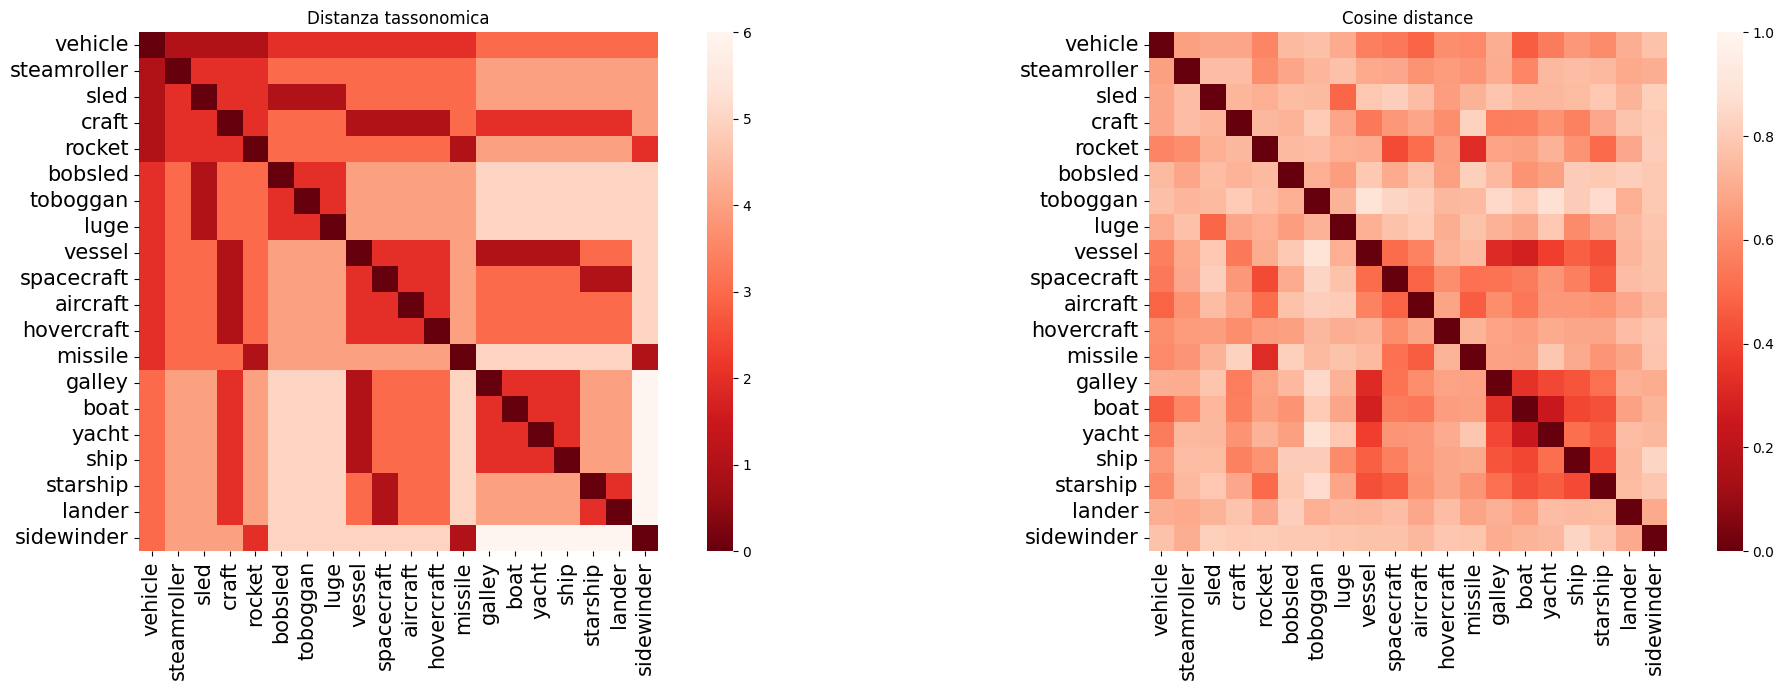

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(21, 7))

# Taxonomic distance
sns.heatmap(
    dist_matrix,
    ax=axes[0],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=6,
    square=True
)

axes[0].set_title("Distanza tassonomica")
axes[0].tick_params(axis="x", rotation=90, labelsize=15)
axes[0].tick_params(axis="y", rotation=0, labelsize=15)

# Cosine distance
sns.heatmap(
    cosine_matrix.to_numpy(),
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels,
    cmap="Reds_r",
    vmin=0,
    vmax=1,
    square=True
)

axes[1].set_title("Cosine distance")
axes[1].tick_params(axis="x", rotation=90, labelsize=15)
axes[1].tick_params(axis="y", rotation=0, labelsize=15)

plt.tight_layout()
plt.show()

In [24]:
#correlazione con il test di mantel
coeff, p_value, n = mantel(dist_matrix, cosine_matrix)
print(f"rho = {round(coeff, 4)}")
print(f"p value = {round(p_value, 4)}")

rho = 0.4441
p value = 0.001


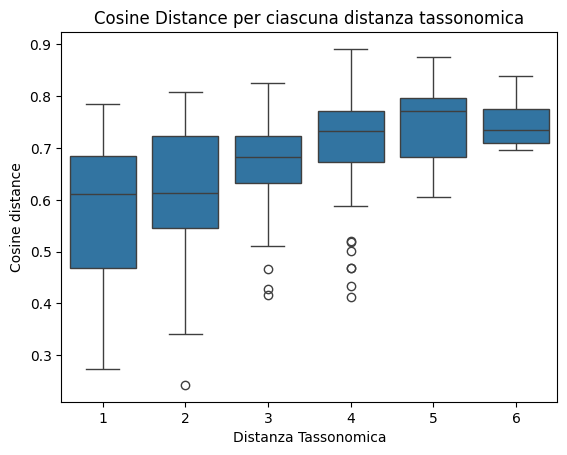

In [18]:
sns.boxplot(
    data=taxonomic_df,
    x="taxonomic_distance",
    y="cosine_distance"
)

plt.xlabel("Distanza Tassonomica")
plt.ylabel("Cosine distance")
plt.title("Cosine Distance per ciascuna distanza tassonomica")
plt.show()

In [ ]:
taxonomic_df.groupby("taxonomic_distance")["cosine_distance"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
taxonomic_distance,,,,,,,,
1,19.0,0.571,0.163,0.274,0.469,0.611,0.684,0.785
2,37.0,0.613,0.135,0.243,0.546,0.613,0.722,0.809
3,49.0,0.665,0.094,0.417,0.632,0.684,0.723,0.826
4,48.0,0.702,0.110,0.413,0.672,0.733,0.771,0.891
5,31.0,0.747,0.072,0.605,0.683,0.771,0.796,0.876
6,6.0,0.749,0.054,0.696,0.711,0.735,0.775,0.838


In [ ]:
#divido in gruppi attesi l'albero tassonomico:

print(list(G.edges()))

[('craft.n.02', 'vessel.n.02'), ('craft.n.02', 'spacecraft.n.01'), ('craft.n.02', 'aircraft.n.01'), ('craft.n.02', 'hovercraft.n.01'), ('vessel.n.02', 'galley.n.01'), ('vessel.n.02', 'boat.n.01'), ('vessel.n.02', 'yacht.n.01'), ('vessel.n.02', 'ship.n.01'), ('spacecraft.n.01', 'starship.n.01'), ('spacecraft.n.01', 'lander.n.02'), ('rocket.n.01', 'missile.n.01'), ('missile.n.01', 'sidewinder.n.02'), ('sled.n.01', 'bobsled.n.01'), ('sled.n.01', 'toboggan.n.01'), ('sled.n.01', 'luge.n.01'), ('vehicle.n.01', 'steamroller.n.02'), ('vehicle.n.01', 'sled.n.01'), ('vehicle.n.01', 'craft.n.02'), ('vehicle.n.01', 'rocket.n.01')]


In [25]:
#riprendo output uscito nel dataset per l'albero
# vehicle
# ├── rocket
# │   ├── missile
# │   │   └── sidewinder
# ├── craft
# │   ├── aircraft
# │   ├── vessel
# │   │   └── galley
# │   │   └── ship
# │   │   └── yacht
# │   │   └── boat
# │   ├── hovercraft
# │   ├── spacecraft
# │   │   └── starship
# │   │   └── lander
# ├── steamroller
# ├── sled
# │   ├── bobsled
# │   ├── luge
# │   ├── toboggan

#dividiamo in cluster l'albero:
gruppi = {
    "rocket": ["rocket", "missile", "sidewinder"],
    
    "craft": [
        "craft", "aircraft", "vessel", "galley", "ship",
        "yacht", "boat", "hovercraft", "spacecraft",
        "starship", "lander"
    ],
    
    "steamroller": ["steamroller"],
    
    "sled": ["sled", "bobsled", "luge", "toboggan"]
}

In [26]:
# si attribuisce il gruppo a ogni parola dell'albero (all_words), 
y_true = []
#è lasciata fuori vehicles in quanto radice
for word in ordered_words:
    if word == "vehicle":
        continue

    for gruppo, parola_di_gruppo in gruppi.items(): #sfogliamo gli items del dizionario
        if word in parola_di_gruppo:
            y_true.append(gruppo)
            break

print(y_true)

['steamroller', 'sled', 'craft', 'rocket', 'sled', 'sled', 'sled', 'craft', 'craft', 'craft', 'craft', 'rocket', 'craft', 'craft', 'craft', 'craft', 'craft', 'craft', 'rocket']


In [27]:
#confronto ARI con 6 clusterizzazioni k-means, usando ARI, si vede qual è la migliore

X = np.array([embeddings[word] for word in cosine_matrix.index])

print(X.shape)
#anche in questo caso tolgo vehicle in quanto radice
X_19 = X[1:]

#creo liste valori K-means e Ari, servono per il successivo grafico
k_values = []
ari_values = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    y_pred = kmeans.fit_predict(X_19)

    ari = adjusted_rand_score(y_true, y_pred)

    k_values.append(k)
    ari_values.append(ari)

    print(f"k = {k}: ARI = {ari:.3f}")

(20, 384)
k = 2: ARI = 0.211
k = 3: ARI = 0.289
k = 4: ARI = 0.259
k = 5: ARI = 0.366
k = 6: ARI = 0.311


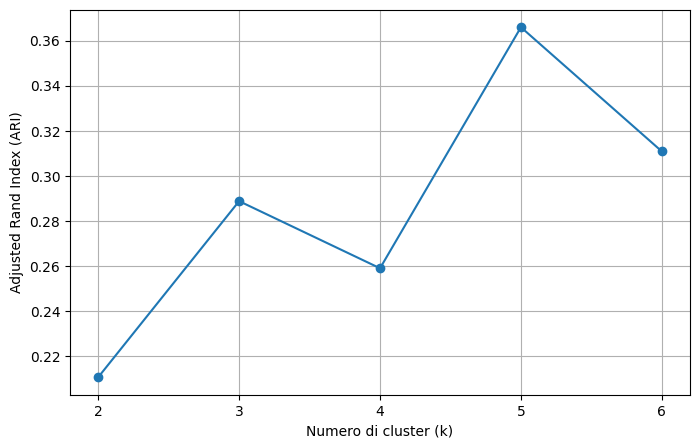

In [28]:
#grafico per capire quale k-mean è migliore
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    ari_values,
    marker="o"
)

plt.xlabel("Numero di cluster (k)")
plt.ylabel("Adjusted Rand Index (ARI)")

plt.xticks(k_values)

plt.grid(True)

plt.savefig("ari_vs_k.png", dpi=300, bbox_inches="tight")


plt.show()

In [30]:
#k-means k=5 vince, vedo la ripartizione
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_19)


In [31]:
#ricreo la cosine matrix senza vehicle però
cosine_matrix_19 = cosine_matrix.drop(
    index="vehicle",
    columns="vehicle")

In [32]:
cluster_df = pd.DataFrame({
    "word": cosine_matrix_19.index,
    "cluster": clusters
})

cluster_df = cluster_df.sort_values("cluster")

print(cluster_df)

           word  cluster
1          sled        0
4       bobsled        0
6          luge        0
2         craft        1
7        vessel        1
13         boat        1
14        yacht        1
15         ship        1
12       galley        1
16     starship        1
0   steamroller        2
10   hovercraft        2
8    spacecraft        3
11      missile        3
9      aircraft        3
3        rocket        3
5      toboggan        4
17       lander        4
18   sidewinder        4


In [33]:
for cluster in sorted(cluster_df["cluster"].unique()):
    
    words = cluster_df[
        cluster_df["cluster"] == cluster
    ]["word"].tolist()
    
    print(f"Cluster {cluster}:")
    print("  " + ", ".join(words))

Cluster 0:
  sled, bobsled, luge
Cluster 1:
  craft, vessel, boat, yacht, ship, galley, starship
Cluster 2:
  steamroller, hovercraft
Cluster 3:
  spacecraft, missile, aircraft, rocket
Cluster 4:
  toboggan, lander, sidewinder


In [34]:
#Gerarchico
#trasformo la matrice in forma scypy: estrae il triangolo superiore della matrice e lo convere in un vettore
distance_vector = squareform(cosine_matrix_19.values)

In [35]:
#faccio confronto ARI tra combinazioni di metodi di Agglomerativeclustering e soglie k a cui raggruppare gli elementi
methods = ["single", "complete", "average"]

finale = []

for metodo in methods:
        
    Z = linkage(
        distance_vector,
        method=metodo
    )
    
    for k in range(2, 7):
        
        y_pred_hierarchical = fcluster(
            Z,
            t=k,
            criterion="maxclust"
            )
        
        ari = adjusted_rand_score(
            y_true,
            y_pred_hierarchical
            )

        finale.append({
            "linkage": metodo,
            "k": k,
            "ARI": ari
        })
        
        print(f"{metodo} | k = {k} | ARI = {ari:.3f}")

single | k = 2 | ARI = 0.073
single | k = 3 | ARI = 0.165
single | k = 4 | ARI = 0.087
single | k = 5 | ARI = 0.170
single | k = 6 | ARI = 0.091
complete | k = 2 | ARI = 0.211
complete | k = 3 | ARI = 0.522
complete | k = 4 | ARI = 0.509
complete | k = 5 | ARI = 0.472
complete | k = 6 | ARI = 0.468
average | k = 2 | ARI = 0.315
average | k = 3 | ARI = 0.306
average | k = 4 | ARI = 0.279
average | k = 5 | ARI = 0.393
average | k = 6 | ARI = 0.404


In [36]:
#selezioniamo la combinazione che porta il risultato migliore

best_result = max(finale, key=lambda x: x["ARI"])

print("\nMiglior configurazione:")
print(f"Linkage: {best_result['linkage']}")
print(f"k: {best_result['k']}")
print(f"ARI: {best_result['ARI']:.3f}")


Miglior configurazione:
Linkage: complete
k: 3
ARI: 0.522


In [37]:
#serve per la costruzione del dendogramma di "complete"
Z_finale = linkage(
        distance_vector,
        method = "complete"
    )


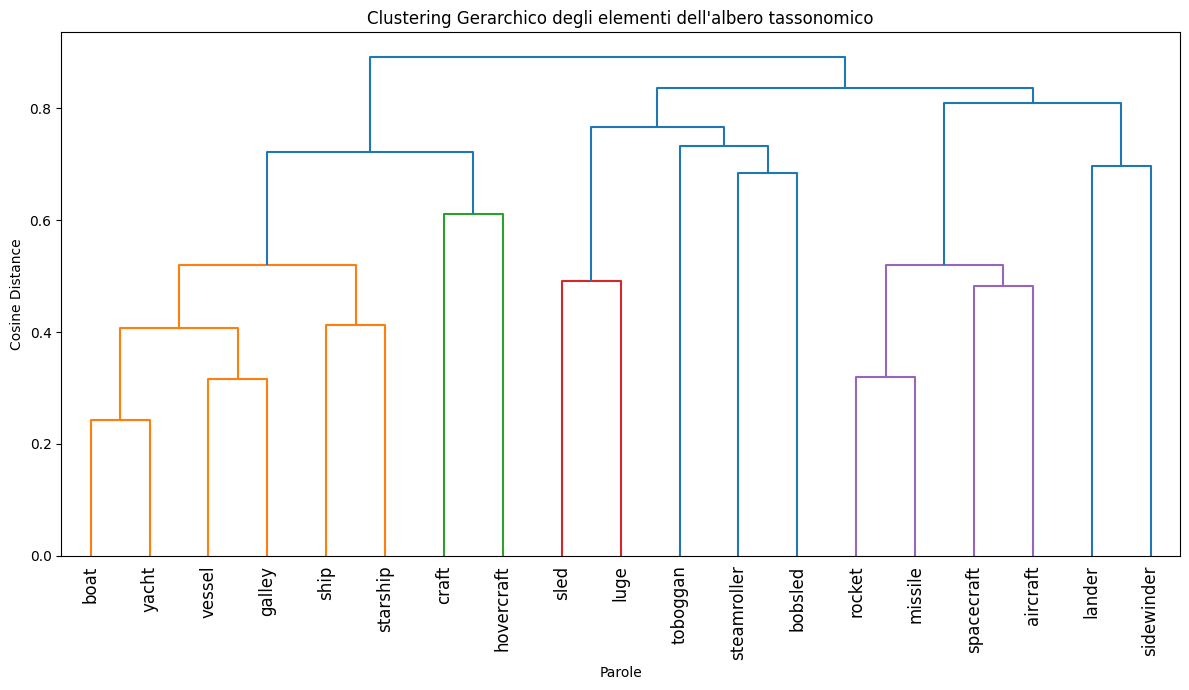

In [38]:
#costruisco il dendrogramma del clustering gerarchico complete
plt.figure(figsize=(12, 7))

dendrogram(
    Z_finale,
    labels=cosine_matrix_19.index.tolist(),
    leaf_rotation=90 #per visualizzare meglio il dendogramma
)

plt.xlabel("Parole")
plt.ylabel("Cosine Distance")
plt.title("Clustering Gerarchico degli elementi dell'albero tassonomico")

plt.tight_layout()
plt.show()